In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


# Classificação de Espécies de Iris com SVM
Disciplina de Inteligência Artificial

Neste notebook, reavaliamos o clássico dataset Iris, utilizando os dados obtidos diretamente do Kaggle (dataset Iris Species, anexado a este notebook). O fluxo de trabalho segue as etapas fundamentais de um projeto de Machine Learning:

Obtenção dos dados (dataset anexado do Kaggle)
Análise Exploratória de Dados (EDA)
Preparação dos dados
Criação do modelo, sendo exclusivamente Support Vector Machine (SVM)
Avaliação dos resultados com métricas clássicas
Dataset: Iris Species

O objetivo é prever a espécie da flor (Iris-setosa, Iris-versicolor ou Iris-virginica) a partir de quatro medidas: comprimento e largura da sépala, e comprimento e largura da pétala.


# 1 - Obtenção dos Dados

O dataset foi anexado automaticamente a este notebook ao criá-lo pela página do dataset no Kaggle (botão **New Notebook**). Os arquivos de entrada ficam disponíveis no diretório `/kaggle/input/`.
Primeiro, importamos as bibliotecas necessárias e listamos os arquivos disponíveis para confirmar que o dataset está corretamente vinculado.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


In [3]:
csv_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.lower().endswith('.csv'):
            csv_path = os.path.join(dirname, filename)
            break

print("Arquivo carregado:", csv_path)

df = pd.read_csv(csv_path)

df.head()

Arquivo carregado: /kaggle/input/datasets/menegidio/iris-species/Iris.csv


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# 2 - Análise Exploratória de Dados (EDA)
Nesta etapa, observamos e descrevemos os dados para entender sua estrutura, distribuição, possíveis inconsistências e as relações entre as variáveis. Uma boa EDA orienta as decisões de preparação dos dados e de modelagem.

**2.1 Estrutura geral do dataset**

In [4]:
print("Dimensões:", df.shape)

df.info()

Dimensões: (150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


O dataset possui **150 amostras** e as colunas com as quatro medidas da flor (em centímetros), além da coluna alvo `Species`. Se houver uma coluna `Id`, ela é apenas um identificador sequencial e não carrega informação preditiva, portanto será removida na preparação dos dados.

### 2.2 Estatísticas descritivas

In [5]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


**Observações:**
- As medidas de pétala (`PetalLengthCm` e `PetalWidthCm`) apresentam maior variabilidade (desvio padrão) do que as de sépala, o que sugere maior poder discriminativo entre as espécies.
- Não há valores absurdos (negativos ou fora de escala), indicando dados consistentes.

### 2.3 Verificação de valores ausentes e duplicados

In [6]:
print("Valores ausentes por coluna:")
print(df.isnull().sum())

print("\nLinhas duplicadas:", df.duplicated().sum())

Valores ausentes por coluna:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Linhas duplicadas: 0


### 2.4 Distribuição da variável alvo (Species)

Verificamos se as classes estão balanceadas, o que é importante para o treinamento e para a interpretação das métricas.

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


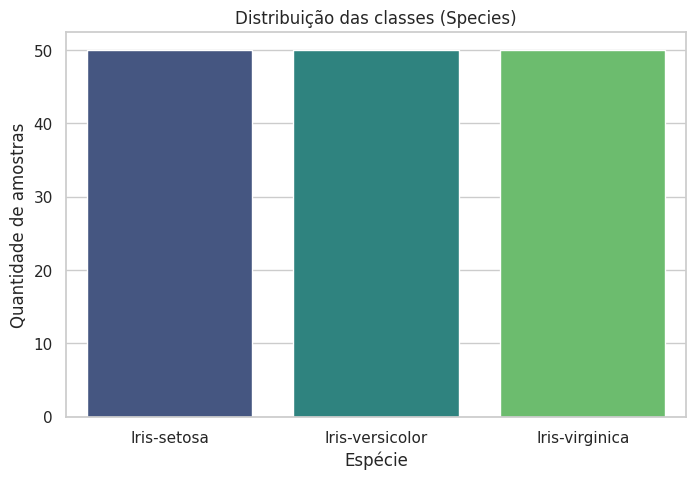

In [7]:
print(df['Species'].value_counts())

ax = sns.countplot(data=df, x='Species', hue='Species', palette='viridis', legend=False)
ax.set_title('Distribuição das classes (Species)')
ax.set_xlabel('Espécie')
ax.set_ylabel('Quantidade de amostras')
plt.show()

**O dataset é perfeitamente balanceado:** 50 amostras de cada espécie. Isso significa que a acurácia é uma métrica confiável e que não precisamos de técnicas de balanceamento.

**2.5 Distribuição das variáveis numéricas por espécie**
Os histogramas e boxplots ajudam a identificar quais características melhor separam as espécies.

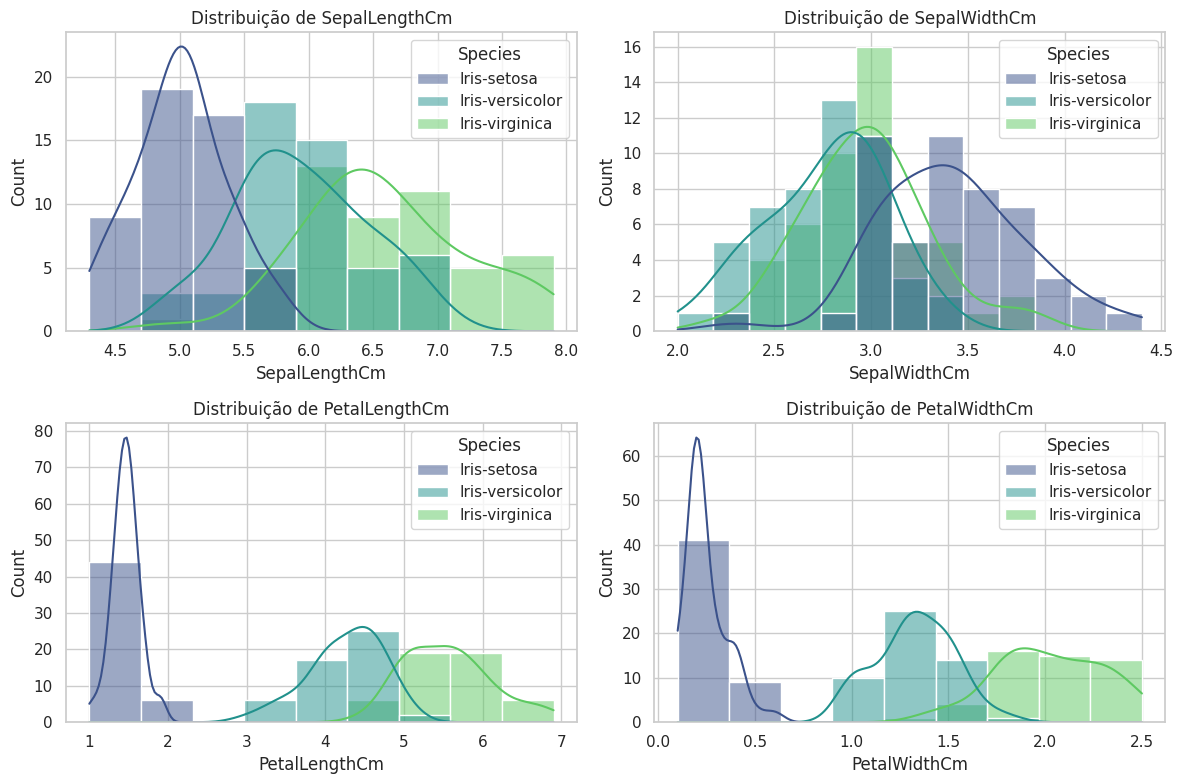

In [8]:
features = [c for c in df.columns if c.endswith('Cm')]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), features):
    sns.histplot(data=df, x=col, hue='Species', kde=True, ax=ax, palette='viridis')
    ax.set_title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

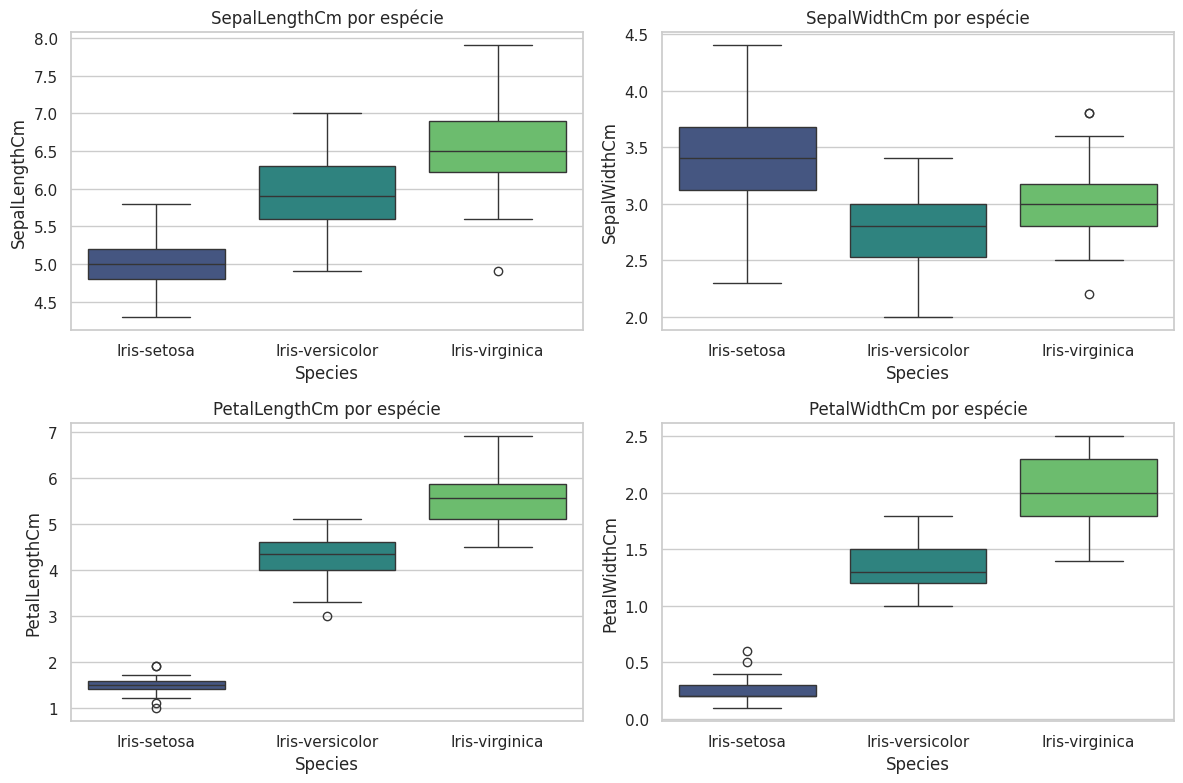

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), features):
    sns.boxplot(data=df, x='Species', y=col, hue='Species', ax=ax, palette='viridis', legend=False)
    ax.set_title(f'{col} por espécie')
plt.tight_layout()
plt.show()

**Observações:**
- A espécie *Iris-setosa* se separa claramente das demais pelas medidas de **pétala** (valores bem menores).
- *Iris-versicolor* e *Iris-virginica* apresentam alguma sobreposição, principalmente nas medidas de sépala — é entre essas duas classes que o modelo pode cometer erros.

### 2.6 Relações entre as variáveis (pairplot e correlação)

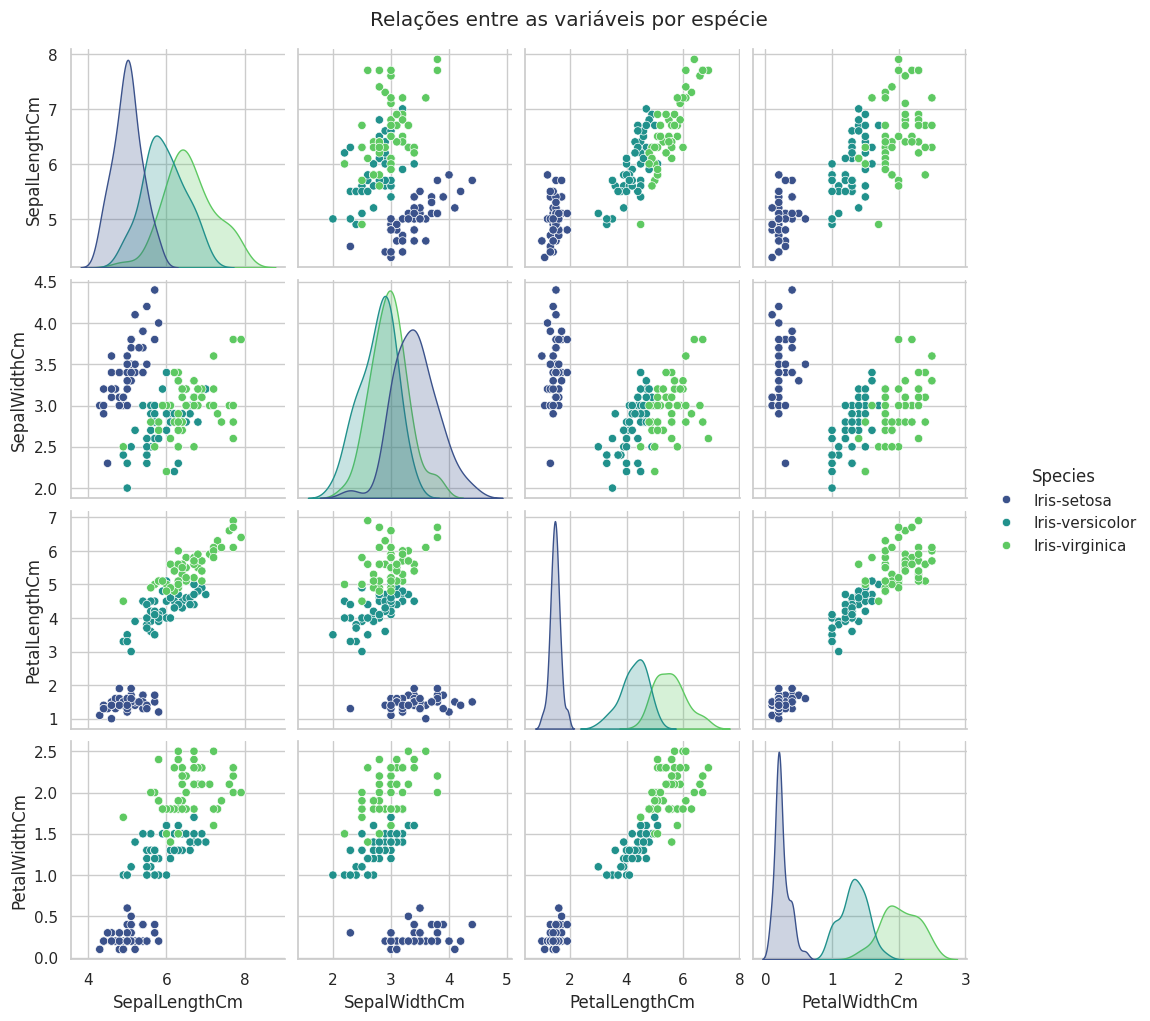

In [10]:
sns.pairplot(df.drop(columns=['Id'], errors='ignore'), hue='Species', palette='viridis')
plt.suptitle('Relações entre as variáveis por espécie', y=1.02)
plt.show()

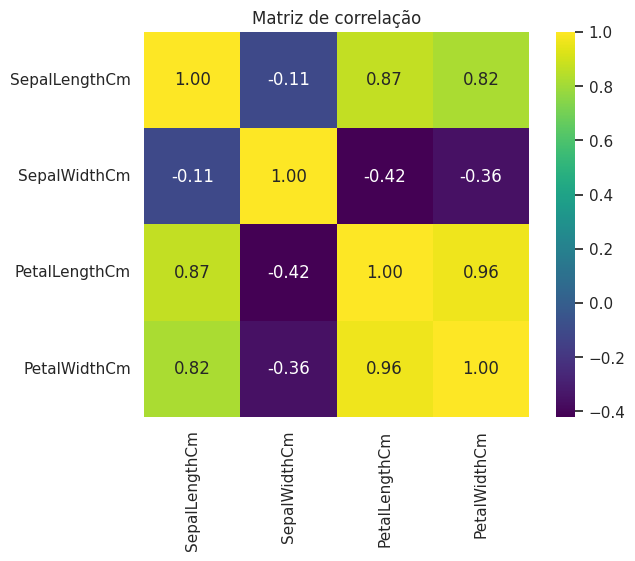

In [11]:
corr = df[features].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='viridis', fmt='.2f', square=True)
plt.title('Matriz de correlação')
plt.show()

**Conclusões da EDA:**
- `PetalLengthCm` e `PetalWidthCm` são altamente correlacionadas entre si (~0,96) e são as variáveis que melhor separam as três espécies.
- *Iris-setosa* é linearmente separável das demais; a fronteira entre *versicolor* e *virginica* é mais sutil — um cenário em que o **SVM**, que busca a fronteira de decisão com **margem máxima**, tende a se sair muito bem.
- Os dados estão limpos (sem ausentes), então a preparação se concentra em separar features/alvo, dividir treino/teste e **padronizar as escalas** (essencial para SVM, que é sensível à escala das variáveis).

## 3. Preparação dos Dados

Etapas realizadas:
1. **Remoção da coluna `Id`** (identificador sem valor preditivo).
2. **Separação** das variáveis preditoras (X) e da variável alvo (y).
3. **Codificação do alvo** com `LabelEncoder` (as espécies viram 0, 1 e 2).
4. **Divisão treino/teste** (80% / 20%), com `stratify` para manter a proporção das classes.
5. **Padronização** com `StandardScaler` — o SVM calcula distâncias entre pontos, então todas as variáveis precisam estar na mesma escala. O scaler é **ajustado apenas no treino** para evitar vazamento de dados (*data leakage*).

In [12]:
df_model = df.drop(columns=['Id'], errors='ignore')

X = df_model.drop(columns=['Species'])
y = df_model['Species']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes:", list(le.classes_))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nMédia das features do treino após padronização (≈0):", X_train_scaled.mean(axis=0).round(3))
print("Desvio padrão após padronização (≈1):", X_train_scaled.std(axis=0).round(3))

Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Treino: (120, 4) | Teste: (30, 4)

Média das features do treino após padronização (≈0): [-0.  0. -0.  0.]
Desvio padrão após padronização (≈1): [1. 1. 1. 1.]


## 4. Criação do Modelo — Support Vector Machine (SVM)

O **SVM** é um algoritmo de classificação que busca o **hiperplano de separação com a maior margem possível** entre as classes. Os pontos mais próximos dessa fronteira são os *vetores de suporte*. Com o *kernel trick*, o SVM também resolve problemas não lineares, projetando os dados em espaços de maior dimensão.

Principais hiperparâmetros:
- **C**: controla o equilíbrio entre margem larga e erros de classificação no treino (regularização).
- **kernel**: tipo de fronteira: `linear`, `rbf`, `poly`...
- **gamma**: alcance da influência de cada amostra (para kernels não lineares).

### 4.1 Modelo base

In [13]:
svm_base = SVC(kernel='rbf', random_state=42)
svm_base.fit(X_train_scaled, y_train)

cv_scores = cross_val_score(svm_base, X_train_scaled, y_train, cv=5)
print("Acurácia por fold:", cv_scores.round(3))
print(f"Acurácia média (CV): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Acurácia por fold: [0.917 1.    0.958 0.958 1.   ]
Acurácia média (CV): 0.9667 (+/- 0.0312)


### 4.2 Ajuste de hiperparâmetros (Grid Search)

Usamos `GridSearchCV` para testar combinações de `C`, `kernel` e `gamma` com validação cruzada, escolhendo a melhor configuração **usando apenas os dados de treino**. Observe que todos os candidatos são variações de SVM, nenhum outro algoritmo é utilizado.

In [14]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 0.01, 0.1, 1]
}

grid = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Melhores hiperparâmetros:", grid.best_params_)
print(f"Melhor acurácia média na validação cruzada: {grid.best_score_:.4f}")

svm_final = grid.best_estimator_

Melhores hiperparâmetros: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Melhor acurácia média na validação cruzada: 0.9833


## 5. Avaliação do Modelo

O modelo final é avaliado no **conjunto de teste**, que não foi usado em nenhuma etapa do treinamento. Utilizamos as métricas clássicas de classificação:

- **Acurácia** — proporção total de acertos.
- **Precisão** — dos exemplos previstos como uma classe, quantos realmente são dela (evita falsos positivos).
- **Recall (revocação)** — dos exemplos reais de uma classe, quantos foram identificados (evita falsos negativos).
- **F1-score** — média harmônica entre precisão e recall.
- **Matriz de confusão** — mostra exatamente onde o modelo acerta e erra.

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

svm_final = SVC(C=0.1, kernel="linear")
svm_final.fit(X_train_scaled, y_train)

y_pred = svm_final.predict(X_test_scaled)

nomes_classes = ["Iris-setosa", "Iris-versicolor", "Iris-virginica"]

print(f"Acurácia : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão : {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred, average='macro'):.4f}")

print("\nRelatório de classificação:\n")
print(classification_report(y_test, y_pred, target_names=nomes_classes))

print("Matriz de confusão:\n")
print(confusion_matrix(y_test, y_pred))

Acurácia : 0.9333
Precisão : 0.9333
Recall   : 0.9333
F1-score : 0.9333

Relatório de classificação:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

Matriz de confusão:

[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


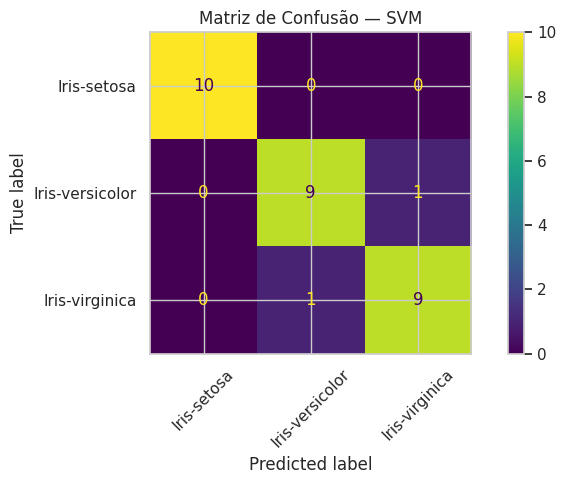

In [16]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='viridis', xticks_rotation=45)
plt.title('Matriz de Confusão — SVM')
plt.tight_layout()
plt.show()

# 5.1 Interpretação dos resultados
A diagonal principal da matriz de confusão concentra os acertos; valores fora dela são erros.
Como antecipado na EDA, Iris-setosa é classificada sem dificuldade. Eventuais erros (se houver) ocorrem entre Iris-versicolor e Iris-virginica, as classes com maior sobreposição.
A combinação de dados bem separáveis, padronização e o ajuste de hiperparâmetros leva o SVM a um desempenho excelente (acurácia próxima ou igual a 100% no teste).
A validação cruzada na etapa de treino confirma que o resultado não é fruto de sorte na divisão dos dados: o modelo generaliza bem.
# 6. Conclusão
Neste notebook, contém todo o fluxo de trabalho de Machine Learning proposto:

Obtenção dos dados diretamente do dataset Kaggle anexado ao notebook (sem uso de load_iris()).
EDA completa: estrutura, estatísticas, ausentes, balanceamento, distribuições, pairplot e correlações.
Preparação: remoção do Id, codificação do alvo, divisão treino/teste estratificada e padronização sem vazamento de dados.
Modelagem exclusivamente com SVM, incluindo validação cruzada e busca de hiperparâmetros (GridSearchCV).
Avaliação com acurácia, precisão, recall, F1-score, relatório de classificação e matriz de confusão, com interpretação dos resultados.
O SVM se mostrou uma escolha muito adequada para este problema: com as pétalas fornecendo forte separação entre as classes e os dados padronizados, o modelo encontra fronteiras de decisão de margem máxima que classificam as três espécies com altíssima precisão.